<a href="https://colab.research.google.com/github/jonathanastudillo-lab/Ejercicio/blob/main/trabajo_unidad_3_ml_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Unidad 3 - Machine Learning

## Algoritmos no supervisados: clustering con y sin PCA

**Base de datos:** House Prices - Advanced Regression Techniques  
**Asignatura:** Machine Learning  

**Profesor:** Franco Andrés Mansilla  
**Fecha:** 09.05.2026

**Integrantes:**
- Jonathan Astudillo Vergara
- Gustavo Gutiérrez Díaz
- Mario Miño Farfán
- Robinson Sánchez Águila
- Leonel Tapia Araya


## Introducción

El objetivo de este trabajo es aplicar algoritmos de aprendizaje no supervisado sobre la base **House Prices**, utilizada en las unidades anteriores. A diferencia de un modelo supervisado, en clustering no se busca predecir directamente `SalePrice`, sino descubrir grupos de viviendas con características similares.

Para evitar sesgo, la variable `SalePrice` se separa desde el inicio y no se utiliza durante el entrenamiento de los algoritmos. Posteriormente, se reincorpora solo para interpretar si los clusters encontrados presentan diferencias coherentes en precio de venta y características de las viviendas.

El trabajo se estructura según la pauta de la Unidad 3:

1. Preparación de datos.
2. Experimento con y sin PCA.
3. Challenge entre algoritmos de distancia y densidad.
4. Evaluación con métricas y análisis respecto a `SalePrice`.
5. Carga del cuaderno en GitHub.

La preparación de datos incorpora ingeniería de variables antes del clustering, porque una codificación directa de variables categóricas puede generar alta dimensionalidad, categorías poco representativas y clusters formados por observaciones aisladas. Por esta razón, se aplican criterios de codificación ordinal, agrupación de categorías poco frecuentes, One-Hot Encoding completo, normalización y selección de modelo considerando tanto métricas internas como representatividad mínima de los clusters.


# Punto 1. Preparación de datos

En este punto se carga la base trabajada en las unidades anteriores y se prepara para algoritmos no supervisados. La preparación incluye separación de `SalePrice`, revisión de nulos, ingeniería de variables, One-Hot Encoding completo, normalización y construcción de una base adecuada para clustering.


In [ ]:
# Importar librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, OPTICS
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Parámetros generales
RANDOM_STATE = 42
TARGET = "SalePrice"

# Configuración visual simple
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

# Cargar base trabajada en unidades anteriores desde GitHub
url = "https://raw.githubusercontent.com/jonathanastudillo-lab/Ejercicio/main/house_prices_base_limpia_sumativo1.csv"
df = pd.read_csv(url)

print("Dimensión inicial de la base:", df.shape)
display(df.head())


Dimensión inicial de la base: (1460, 73)


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450.0,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003.0,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,854.0,0,1710.0,1,0,2,1,3,1,Gd,Typ,0,NaN,Attchd,2003.0,RFn,2,TA,TA,Y,0.0,61.0,0.00,0,0.0,0,0,2,2008,WD,Normal,208500.0
1,20,RL,80.0,9600.0,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976.0,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,0.0,0,1262.0,0,1,2,0,3,1,TA,Typ,1,TA,Attchd,1976.0,RFn,2,TA,TA,Y,298.0,0.0,0.00,0,0.0,0,0,5,2007,WD,Normal,181500.0
2,60,RL,68.0,11250.0,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001.0,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,866.0,0,1786.0,1,0,2,1,3,1,Gd,Typ,1,TA,Attchd,2001.0,RFn,2,TA,TA,Y,0.0,42.0,0.00,0,0.0,0,0,9,2008,WD,Normal,223500.0
3,70,RL,60.0,9550.0,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915.0,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,756.0,0,1717.0,1,0,1,0,3,1,Gd,Typ,1,Gd,Detchd,1998.0,Unf,3,TA,TA,Y,0.0,35.0,261.05,0,0.0,0,0,2,2006,WD,Abnorml,140000.0
4,60,RL,84.0,14260.0,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000.0,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1053.0,0,2198.0,1,0,2,1,4,1,Gd,Typ,1,TA,Attchd,2000.0,RFn,3,TA,TA,Y,192.0,84.0,0.00,0,0.0,0,0,12,2008,WD,Normal,250000.0


In [ ]:
# Resumen inicial de la base
resumen_inicial = pd.DataFrame({
    "Indicador": [
        "Filas",
        "Columnas totales",
        "Contiene SalePrice",
        "Contiene Id"
    ],
    "Valor": [
        df.shape[0],
        df.shape[1],
        TARGET in df.columns,
        "Id" in df.columns
    ]
})

display(resumen_inicial)


,Indicador,Valor
0,Filas,1460
1,Columnas totales,73
2,Contiene SalePrice,True
3,Contiene Id,False


## Justificación de la base utilizada

Se utiliza la base trabajada en las unidades anteriores para mantener continuidad metodológica. Aunque la base ya fue preparada previamente, se realiza una revisión complementaria porque el clustering requiere una estructura específica: datos numéricos, sin nulos y en escala comparable.

La variable `SalePrice` se mantiene en la base original, pero se separa antes del entrenamiento porque el objetivo del clustering es descubrir grupos sin utilizar una respuesta conocida. Posteriormente, `SalePrice` se reincorpora solo para interpretar si los clusters presentan diferencias de precio.


In [ ]:
# Separar variable objetivo para evitar sesgo en clustering
y = df[TARGET].copy()
X = df.drop(columns=[TARGET]).copy()

# Eliminar Id si existe, porque es solo un identificador y no una característica de la vivienda
if "Id" in X.columns:
    X = X.drop(columns=["Id"])

print("Dimensión de X antes de ingeniería de variables:", X.shape)
print("Dimensión de y:", y.shape)


Dimensión de X antes de ingeniería de variables: (1460, 72)
Dimensión de y: (1460,)


## 1.1 Ingeniería de variables antes del One-Hot Encoding

Antes de codificar las variables categóricas, se revisa su significado. Esta decisión es importante porque no todas las variables deben tratarse igual:

1. `MSSubClass` se convierte a categórica, porque representa un código de tipo de vivienda.
2. `MoSold` y `YrSold` se eliminan, porque representan el momento de venta y pueden agregar ruido si el objetivo es agrupar viviendas por características estructurales.
3. Algunas variables ordinales se transforman a escala numérica, conservando su orden natural.
4. Las categorías poco frecuentes se agrupan bajo la etiqueta `Otros`.

Esta etapa evita que el modelo interprete códigos como magnitudes continuas o que categorías muy pequeñas generen columnas binarias excesivamente específicas.


In [ ]:
# Copia de trabajo
X_work = X.copy()

# 1) MSSubClass es un código de tipo de vivienda, no una magnitud continua
if "MSSubClass" in X_work.columns:
    X_work["MSSubClass"] = X_work["MSSubClass"].astype(str)

# 2) Eliminar variables temporales de venta para enfocar el clustering en características de la vivienda
cols_eliminar = ["MoSold", "YrSold"]
cols_eliminadas = [col for col in cols_eliminar if col in X_work.columns]
X_work = X_work.drop(columns=cols_eliminadas)

print("Columnas eliminadas:", cols_eliminadas)
print("Dimensión después de eliminar variables temporales:", X_work.shape)


Columnas eliminadas: ['MoSold', 'YrSold']
Dimensión después de eliminar variables temporales: (1460, 70)


## Justificación de `MSSubClass`, `MoSold` y `YrSold`

`MSSubClass` se trata como categórica porque representa una clase o tipo de vivienda. Si se mantiene como número, el modelo podría interpretar distancias artificiales entre códigos. Por ejemplo, una clase 60 no significa el triple de una clase 20; son tipos distintos de vivienda.

`MoSold` y `YrSold` se eliminan porque representan el mes y año de venta. Para este análisis, el objetivo es agrupar viviendas por atributos estructurales, calidad, superficie, garaje, baños y ubicación. Mantener variables temporales podría generar agrupamientos asociados al momento de venta y no necesariamente a similitudes inmobiliarias.


In [ ]:
# Identificar variables numéricas y categóricas antes del tratamiento de nulos
num_cols_pre = X_work.select_dtypes(include=np.number).columns.tolist()
cat_cols_pre = X_work.select_dtypes(exclude=np.number).columns.tolist()

print("Variables numéricas antes de ingeniería ordinal:", len(num_cols_pre))
print("Variables categóricas antes de ingeniería ordinal:", len(cat_cols_pre))
print("Nulos antes del tratamiento:", X_work.isna().sum().sum())

# Tratamiento de nulos
# Numéricas: mediana
# Categóricas: SinDato
for col in num_cols_pre:
    X_work[col] = X_work[col].fillna(X_work[col].median())

for col in cat_cols_pre:
    X_work[col] = X_work[col].fillna("SinDato")

print("Nulos después del tratamiento:", X_work.isna().sum().sum())


Variables numéricas antes de ingeniería ordinal: 30
Variables categóricas antes de ingeniería ordinal: 40
Nulos antes del tratamiento: 2073
Nulos después del tratamiento: 0


## 1.2 Conversión de variables ordinales

Algunas variables categóricas poseen un orden natural. Por ejemplo, los códigos de calidad y condición representan niveles jerárquicos:

| Código | Significado | Valor asignado |
|---|---|---:|
| `Ex` | Excellent / Excelente | 5 |
| `Gd` | Good / Bueno | 4 |
| `TA` | Typical/Average / Típico o promedio | 3 |
| `Fa` | Fair / Regular | 2 |
| `Po` | Poor / Malo | 1 |
| `SinDato` | Sin información o no aplica | 0 |

Esta transformación conserva la relación de orden. Una vivienda con calidad `Ex` queda más cercana a `Gd` que a `Po`, lo que no se representa correctamente con One-Hot Encoding. Por esta razón, las variables ordinales se transforman a escala numérica antes de aplicar One-Hot a las variables nominales restantes.


In [ ]:
# Mapas ordinales
map_calidad = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "SinDato": 0}
map_bsmt_exposure = {"Gd": 4, "Av": 3, "Mn": 2, "No": 1, "SinDato": 0}
map_finish = {"Fin": 3, "RFn": 2, "Unf": 1, "SinDato": 0}
map_fintype = {"GLQ": 6, "ALQ": 5, "BLQ": 4, "Rec": 3, "LwQ": 2, "Unf": 1, "SinDato": 0}
map_functional = {"Typ": 7, "Min1": 6, "Min2": 5, "Mod": 4, "Maj1": 3, "Maj2": 2, "Sev": 1, "Sal": 0, "SinDato": 0}
map_lotshape = {"Reg": 4, "IR1": 3, "IR2": 2, "IR3": 1, "SinDato": 0}
map_landslope = {"Gtl": 3, "Mod": 2, "Sev": 1, "SinDato": 0}
map_paveddrive = {"Y": 3, "P": 2, "N": 1, "SinDato": 0}

ordinal_maps = {
    "ExterQual": map_calidad,
    "ExterCond": map_calidad,
    "BsmtQual": map_calidad,
    "BsmtCond": map_calidad,
    "HeatingQC": map_calidad,
    "KitchenQual": map_calidad,
    "FireplaceQu": map_calidad,
    "GarageQual": map_calidad,
    "GarageCond": map_calidad,
    "PoolQC": map_calidad,
    "BsmtExposure": map_bsmt_exposure,
    "GarageFinish": map_finish,
    "BsmtFinType1": map_fintype,
    "BsmtFinType2": map_fintype,
    "Functional": map_functional,
    "LotShape": map_lotshape,
    "LandSlope": map_landslope,
    "PavedDrive": map_paveddrive
}

ordinales_transformadas = []

for col, mapa in ordinal_maps.items():
    if col in X_work.columns:
        X_work[col] = X_work[col].map(mapa).fillna(0)
        ordinales_transformadas.append(col)

print("Cantidad de variables ordinales transformadas:", len(ordinales_transformadas))
print("Variables ordinales transformadas:")
print(ordinales_transformadas)


Cantidad de variables ordinales transformadas: 17
Variables ordinales transformadas:
['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'BsmtExposure', 'GarageFinish', 'BsmtFinType1', 'BsmtFinType2', 'Functional', 'LotShape', 'LandSlope', 'PavedDrive']


## 1.3 Agrupación de categorías poco frecuentes

Antes del One-Hot Encoding se agrupan categorías poco frecuentes bajo la etiqueta `Otros`. El criterio utilizado es un mínimo de **20 observaciones por categoría**, equivalente aproximadamente al **1,37%** de la base de 1460 viviendas.

Esto significa que toda categoría con menos de 20 registros se reemplaza por `Otros` dentro de su misma variable. Esta decisión busca evitar que categorías con muy pocos registros creen columnas One-Hot demasiado específicas, lo que puede distorsionar las distancias y favorecer clusters formados por una o pocas observaciones.

El umbral de 20 observaciones es un criterio práctico de representatividad, no una regla universal. Se utiliza porque permite reducir categorías muy pequeñas sin eliminar completamente su información.


In [ ]:
# Agrupar categorías poco frecuentes como "Otros"
MIN_FRECUENCIA = 20

cat_cols = X_work.select_dtypes(exclude=np.number).columns.tolist()
resumen_agrupacion = []

for col in cat_cols:
    frecuencias = X_work[col].value_counts()
    categorias_antes = X_work[col].nunique()
    categorias_bajas = frecuencias[frecuencias < MIN_FRECUENCIA].index.tolist()
    registros_afectados = X_work[col].isin(categorias_bajas).sum()

    X_work[col] = X_work[col].where(~X_work[col].isin(categorias_bajas), "Otros")
    categorias_despues = X_work[col].nunique()

    resumen_agrupacion.append({
        "Variable": col,
        "Categorías antes": categorias_antes,
        "Categorías agrupadas": len(categorias_bajas),
        "Registros afectados": registros_afectados,
        "Categorías después": categorias_despues
    })

resumen_agrupacion = pd.DataFrame(resumen_agrupacion)

print("Variables categóricas evaluadas para agrupación:", len(cat_cols))
print("Categorías totales antes de agrupar:", resumen_agrupacion["Categorías antes"].sum())
print("Categorías agrupadas como Otros:", resumen_agrupacion["Categorías agrupadas"].sum())
print("Categorías totales después de agrupar:", resumen_agrupacion["Categorías después"].sum())
print("Variables con al menos una categoría agrupada:", (resumen_agrupacion["Categorías agrupadas"] > 0).sum())

display(resumen_agrupacion.sort_values(by="Categorías agrupadas", ascending=False).head(20))


Variables categóricas evaluadas para agrupación: 23
Categorías totales antes de agrupar: 178
Categorías agrupadas como Otros: 73
Categorías totales después de agrupar: 125
Variables con al menos una categoría agrupada: 20


,Variable,Categorías antes,Categorías agrupadas,Registros afectados,Categorías después
8,Condition2,8,7,15,2
12,RoofMatl,8,7,26,2
6,Neighborhood,25,6,72,20
21,SaleType,9,6,28,4
14,Exterior2nd,16,6,27,11
7,Condition1,9,5,45,5
13,Exterior1st,15,5,7,11
17,Heating,6,5,32,2
0,MSSubClass,15,4,42,12
11,RoofStyle,6,4,33,3


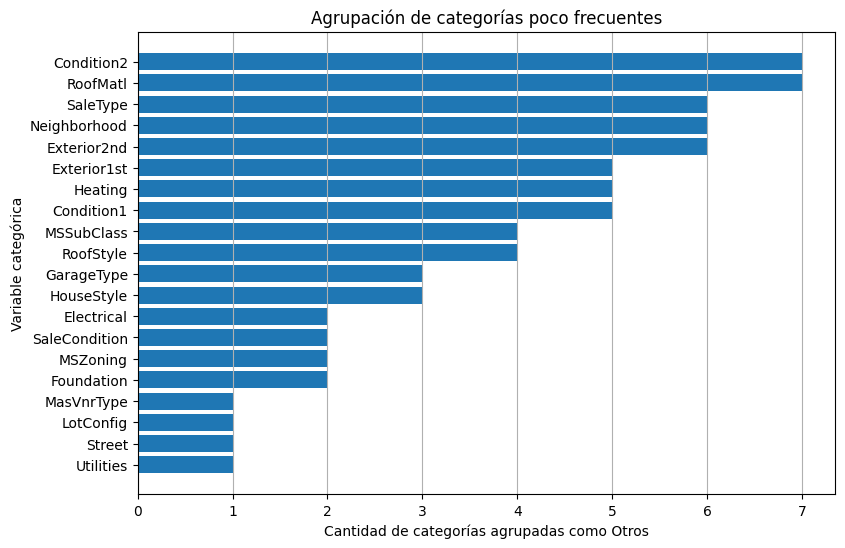

In [ ]:
# Gráfico: categorías agrupadas por variable
resumen_plot = resumen_agrupacion[resumen_agrupacion["Categorías agrupadas"] > 0].copy()
resumen_plot = resumen_plot.sort_values(by="Categorías agrupadas", ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(resumen_plot["Variable"], resumen_plot["Categorías agrupadas"])
plt.xlabel("Cantidad de categorías agrupadas como Otros")
plt.ylabel("Variable categórica")
plt.title("Agrupación de categorías poco frecuentes")
plt.grid(axis="x")
plt.show()


## Interpretación de la agrupación de categorías

El resumen anterior permite cuantificar cuántas categorías fueron agrupadas como `Otros`. Esta etapa es relevante porque el One-Hot Encoding transforma cada categoría en una columna binaria. Por lo tanto, categorías con muy pocos casos pueden aumentar innecesariamente la dimensionalidad y generar observaciones demasiado particulares para los algoritmos de distancia.

Agrupar categorías poco frecuentes no elimina información; la consolida en una categoría común, reduciendo fragmentación y favoreciendo clusters más representativos.


## 1.4 One-Hot Encoding completo

Se aplica One-Hot Encoding completo, es decir, con `drop_first=False`. A diferencia de modelos lineales, donde suele eliminarse una categoría para evitar multicolinealidad, en clustering interesa que todas las categorías queden representadas de forma equivalente en el espacio de distancias.

Por ejemplo, si una categoría se omite, queda representada como todas las dummies en cero. En modelos basados en distancia esto puede ser menos conveniente, porque una categoría queda implícita y no explícitamente representada.


In [ ]:
# Recalcular columnas numéricas y categóricas después de ingeniería
num_cols = X_work.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_work.select_dtypes(exclude=np.number).columns.tolist()
columnas_antes_ohe = X_work.shape[1]

# One-Hot completo
X_ohe = pd.get_dummies(X_work, columns=cat_cols, drop_first=False)

print("Variables numéricas finales:", len(num_cols))
print("Variables categóricas finales:", len(cat_cols))
print("Columnas antes de One-Hot:", columnas_antes_ohe)
print("Columnas después de One-Hot:", X_ohe.shape[1])
print("Columnas generadas por One-Hot:", X_ohe.shape[1] - len(num_cols))

display(X_ohe.head())

# Validación específica: ejemplo con SaleCondition
columnas_salecondition = [col for col in X_ohe.columns if col.startswith("SaleCondition_")]
print("Columnas One-Hot creadas para SaleCondition:")
print(columnas_salecondition)


Variables numéricas finales: 47
Variables categóricas finales: 23
Columnas antes de One-Hot: 70
Columnas después de One-Hot: 172
Columnas generadas por One-Hot: 125


,LotFrontage,LotArea,LotShape,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,Functional,Fireplaces,FireplaceQu,GarageYrBlt,GarageFinish,GarageCars,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MSSubClass_120,MSSubClass_160,MSSubClass_190,MSSubClass_20,MSSubClass_30,MSSubClass_50,MSSubClass_60,MSSubClass_70,MSSubClass_80,MSSubClass_85,MSSubClass_90,MSSubClass_Otros,MSZoning_FV,MSZoning_Otros,MSZoning_RL,MSZoning_RM,Street_Otros,Street_Pave,LandContour_Bnk,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_AllPub,Utilities_Otros,LotConfig_Corner,LotConfig_CulDSac,LotConfig_FR2,LotConfig_Inside,LotConfig_Otros,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_Otros,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Condition1_Artery,Condition1_Feedr,Condition1_Norm,Condition1_Otros,Condition1_RRAn,Condition2_Norm,Condition2_Otros,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Fin,HouseStyle_1Story,HouseStyle_2Story,HouseStyle_Otros,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Gable,RoofStyle_Hip,RoofStyle_Otros,RoofMatl_CompShg,RoofMatl_Otros,Exterior1st_AsbShng,Exterior1st_BrkFace,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_MetalSd,Exterior1st_Otros,Exterior1st_Plywood,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsbShng,Exterior2nd_BrkFace,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_MetalSd,Exterior2nd_Otros,Exterior2nd_Plywood,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkFace,MasVnrType_Otros,MasVnrType_SinDato,MasVnrType_Stone,Foundation_BrkTil,Foundation_CBlock,Foundation_Otros,Foundation_PConc,Foundation_Slab,Heating_GasA,Heating_Otros,CentralAir_N,CentralAir_Y,Electrical_FuseA,Electrical_FuseF,Electrical_Otros,Electrical_SBrkr,GarageType_Attchd,GarageType_BuiltIn,GarageType_Detchd,GarageType_Otros,GarageType_SinDato,SaleType_COD,SaleType_New,SaleType_Otros,SaleType_WD,SaleCondition_Abnorml,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Otros,SaleCondition_Partial
0,65.0,8450.0,4,3,7,5,2003.0,2003,196.0,4,3,4,3,1,6,706.0,1,0.0,150.0,856.0,5,854.0,0,1710.0,1,0,2,1,3,1,4,7,0,0,2003.0,2,2,3,3,3,0.0,61.0,0.00,0,0.0,0,0,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,True,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,True,False,False,True,False,False,False,True,True,False,False,False,False,False,False,False,True,False,False,True,False,False
1,80.0,9600.0,4,3,6,8,1976.0,1976,0.0,3,3,4,3,4,5,978.0,1,0.0,284.0,1262.0,5,0.0,0,1262.0,0,1,2,0,3,1,3,7,1,3,1976.0,2,2,3,3,3,298.0,0.0,0.00,0,0.0,0,0,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,Fal

Columnas One-Hot creadas para SaleCondition:
['SaleCondition_Abnorml', 'SaleCondition_Family', 'SaleCondition_Normal', 'SaleCondition_Otros', 'SaleCondition_Partial']


## Interpretación del One-Hot completo

El One-Hot Encoding se aplicó solo a las variables categóricas finales. Las variables numéricas permanecieron como numéricas y posteriormente fueron normalizadas.

El uso de `drop_first=False` permite que todas las categorías queden visibles como columnas binarias. Esto es especialmente relevante en clustering, porque los algoritmos trabajan con distancias y no con coeficientes de regresión.


## 1.5 Normalización

Los algoritmos de clustering comparan observaciones mediante distancias o densidades. Si las variables tienen escalas distintas, una variable con valores grandes puede dominar el cálculo de distancia.

Por esta razón, se aplica `StandardScaler`, dejando las variables en una escala comparable.


In [ ]:
# Normalización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_ohe)

print("Dimensión final de la base normalizada:", X_scaled.shape)
print("Promedio aproximado de las variables normalizadas:", round(X_scaled.mean(), 4))
print("Desviación estándar aproximada:", round(X_scaled.std(), 4))


Dimensión final de la base normalizada: (1460, 172)
Promedio aproximado de las variables normalizadas: -0.0
Desviación estándar aproximada: 0.9971


## Justificación del Punto 1

La preparación de datos transforma la base en una estructura adecuada para clustering. En este punto se separó `SalePrice` para evitar sesgo, se eliminaron variables temporales que podían introducir ruido, se corrigió el tratamiento de `MSSubClass`, se transformaron variables ordinales conservando su jerarquía, se agruparon categorías poco frecuentes y se aplicó One-Hot completo.

Finalmente, se normalizó la base porque los algoritmos usados en este trabajo comparan observaciones mediante distancias. Esta preparación permite que el análisis no dependa de escalas distintas ni de categorías excesivamente fragmentadas.


# Punto 2. Experimento con y sin PCA

En este punto se construyen varias bases de análisis:

1. **Base sin PCA:** conserva todas las variables transformadas y normalizadas.
2. **Base con PCA 80%:** conserva al menos 80% de la varianza acumulada.
3. **Base con PCA 90%:** conserva al menos 90% de la varianza acumulada.
4. **Base con PCA 95%:** conserva al menos 95% de la varianza acumulada.

La decisión de probar 80%, 90% y 95% se basa en el criterio de analizar y seleccionar un número de componentes menor que el total original, conservando una proporción relevante de la varianza acumulada.


In [ ]:
# PCA completo para analizar varianza acumulada
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

umbrales = [0.80, 0.90, 0.95]
componentes_por_umbral = {}

for umbral in umbrales:
    n_comp = np.argmax(varianza_acumulada >= umbral) + 1
    componentes_por_umbral[umbral] = n_comp

resumen_pca = pd.DataFrame({
    "Umbral de varianza": ["80%", "90%", "95%"],
    "Componentes seleccionados": [
        componentes_por_umbral[0.80],
        componentes_por_umbral[0.90],
        componentes_por_umbral[0.95]
    ],
    "Varianza acumulada real": [
        varianza_acumulada[componentes_por_umbral[0.80]-1],
        varianza_acumulada[componentes_por_umbral[0.90]-1],
        varianza_acumulada[componentes_por_umbral[0.95]-1]
    ]
})

resumen_pca["Varianza acumulada real"] = resumen_pca["Varianza acumulada real"].round(4)
display(resumen_pca)


,Umbral de varianza,Componentes seleccionados,Varianza acumulada real
0,80%,61,0.8023
1,90%,83,0.9027
2,95%,99,0.9518


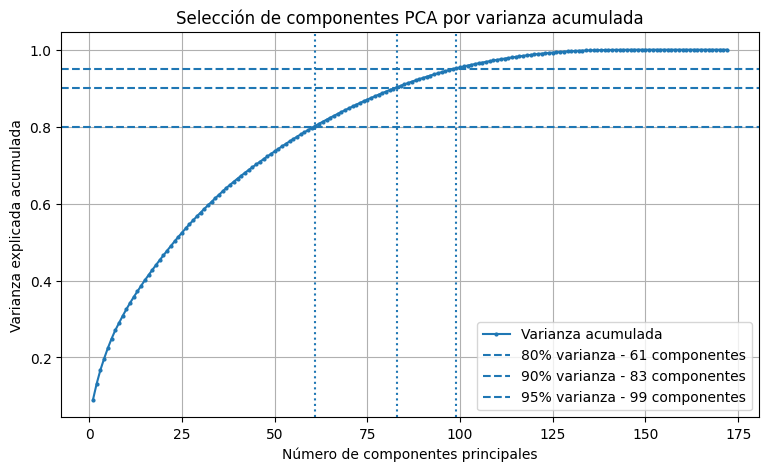

In [ ]:
# Gráfico de varianza acumulada con cantidad de componentes en la leyenda

plt.figure(figsize=(9,5))
plt.plot(
    range(1, len(varianza_acumulada) + 1),
    varianza_acumulada,
    marker="o",
    markersize=2,
    label="Varianza acumulada"
)

for umbral, n_comp in componentes_por_umbral.items():
    plt.axhline(
        y=umbral,
        linestyle="--",
        label=f"{int(umbral*100)}% varianza - {n_comp} componentes"
    )
    plt.axvline(
        x=n_comp,
        linestyle=":"
    )

plt.xlabel("Número de componentes principales")
plt.ylabel("Varianza explicada acumulada")
plt.title("Selección de componentes PCA por varianza acumulada")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Construir bases con y sin PCA
bases = [("Sin PCA", X_scaled)]
X_por_base = {"Sin PCA": X_scaled}

for umbral, n_comp in componentes_por_umbral.items():
    pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X_scaled)
    nombre = f"PCA {int(umbral*100)}%"
    bases.append((nombre, X_pca))
    X_por_base[nombre] = X_pca

resumen_bases = pd.DataFrame({
    "Base": [nombre for nombre, _ in bases],
    "Filas": [X_base.shape[0] for _, X_base in bases],
    "Columnas / Componentes": [X_base.shape[1] for _, X_base in bases]
})

display(resumen_bases)


,Base,Filas,Columnas / Componentes
0,Sin PCA,1460,172
1,PCA 80%,1460,61
2,PCA 90%,1460,83
3,PCA 95%,1460,99


## Justificación del Punto 2

PCA permite comparar si los algoritmos funcionan mejor con todas las variables transformadas o con una representación más compacta de la información. La base sin PCA conserva toda la información codificada, mientras que las bases con PCA reducen la dimensionalidad manteniendo entre 80% y 95% de la varianza acumulada.

Esta comparación es necesaria porque una base con muchas columnas puede dificultar los algoritmos basados en distancia. Sin embargo, reducir demasiado la información también puede afectar la interpretación. Por eso se prueban tres umbrales de PCA dentro del rango recomendado por la materia.


# Punto 3. Challenge entre algoritmos

Se comparan cinco algoritmos de clustering, incluyendo métodos basados en distancia, jerárquicos y densidad:

| Tipo | Algoritmo |
|---|---|
| Distancia | K-Means |
| Distancia / Jerárquico | Agglomerative Ward |
| Distancia / Jerárquico | Agglomerative Complete |
| Densidad | DBSCAN |
| Densidad | OPTICS |

El objetivo es no depender de un solo enfoque de agrupamiento y evaluar cómo responde la base ante distintas lógicas de segmentación.


In [ ]:
# Tabla de modelos evaluados
modelos_challenge = pd.DataFrame({
    "Tipo": [
        "Distancia",
        "Distancia / Jerárquico",
        "Distancia / Jerárquico",
        "Densidad",
        "Densidad"
    ],
    "Algoritmo": [
        "K-Means",
        "Agglomerative Ward",
        "Agglomerative Complete",
        "DBSCAN",
        "OPTICS"
    ]
})

display(modelos_challenge)


,Tipo,Algoritmo
0,Distancia,K-Means
1,Distancia / Jerárquico,Agglomerative Ward
2,Distancia / Jerárquico,Agglomerative Complete
3,Densidad,DBSCAN
4,Densidad,OPTICS


In [ ]:
# Función de evaluación de clustering

def evaluar_resultado(modelo, base, X_base, labels, k=np.nan, eps=np.nan, min_samples=np.nan):
    labels = np.array(labels)

    ruido = np.sum(labels == -1)
    total = len(labels)
    porcentaje_agrupado = round((total - ruido) / total, 4)
    clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Tamaño de clusters reales, sin contar ruido
    labels_sin_ruido = labels[labels != -1]

    if len(labels_sin_ruido) > 0:
        conteo = pd.Series(labels_sin_ruido).value_counts()
        min_cluster = conteo.min()
        max_cluster = conteo.max()
        min_cluster_pct = round(min_cluster / total, 4)
        max_cluster_pct = round(max_cluster / total, 4)
    else:
        min_cluster = 0
        max_cluster = 0
        min_cluster_pct = 0
        max_cluster_pct = 0

    # Para métricas, excluir ruido si existe
    if ruido > 0:
        mask = labels != -1
        X_eval = X_base[mask]
        labels_eval = labels[mask]
    else:
        X_eval = X_base
        labels_eval = labels

    n_labels = len(np.unique(labels_eval))

    if n_labels >= 2 and n_labels < len(labels_eval):
        sil = silhouette_score(X_eval, labels_eval)
        db = davies_bouldin_score(X_eval, labels_eval)
        ch = calinski_harabasz_score(X_eval, labels_eval)
    else:
        sil = np.nan
        db = np.nan
        ch = np.nan

    return {
        "Base": base,
        "Modelo": modelo,
        "K": k,
        "eps": eps,
        "min_samples": min_samples,
        "Clusters": clusters,
        "Ruido": ruido,
        "Porcentaje_agrupado": porcentaje_agrupado,
        "Min_cluster": min_cluster,
        "Max_cluster": max_cluster,
        "Min_cluster_pct": min_cluster_pct,
        "Max_cluster_pct": max_cluster_pct,
        "Silhouette": sil,
        "Davies_Bouldin": db,
        "Calinski_Harabasz": ch
    }


In [ ]:
# Ejecutar challenge entre algoritmos
resultados = []
K_VALUES = range(2, 11)

for nombre_base, X_base in bases:
    print("Ejecutando modelos sobre base:", nombre_base)

    # K-Means
    for k in K_VALUES:
        modelo = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = modelo.fit_predict(X_base)
        resultados.append(evaluar_resultado("K-Means", nombre_base, X_base, labels, k=k))

    # Agglomerative Ward
    for k in K_VALUES:
        modelo = AgglomerativeClustering(n_clusters=k, linkage="ward")
        labels = modelo.fit_predict(X_base)
        resultados.append(evaluar_resultado("Agglomerative Ward", nombre_base, X_base, labels, k=k))

    # Agglomerative Complete
    for k in K_VALUES:
        modelo = AgglomerativeClustering(n_clusters=k, linkage="complete")
        labels = modelo.fit_predict(X_base)
        resultados.append(evaluar_resultado("Agglomerative Complete", nombre_base, X_base, labels, k=k))

    # DBSCAN
    min_samples_dbscan = 5
    vecinos = NearestNeighbors(n_neighbors=min_samples_dbscan)
    vecinos.fit(X_base)
    distancias = vecinos.kneighbors(X_base)[0][:, -1]
    eps_values = np.quantile(distancias, [0.70, 0.80, 0.90, 0.95])
    eps_values = sorted(set(np.round(eps_values, 2)))

    for eps in eps_values:
        modelo = DBSCAN(eps=eps, min_samples=min_samples_dbscan)
        labels = modelo.fit_predict(X_base)
        resultados.append(evaluar_resultado("DBSCAN", nombre_base, X_base, labels, eps=eps, min_samples=min_samples_dbscan))

    # OPTICS
    for min_s in [5, 10]:
        modelo = OPTICS(min_samples=min_s, xi=0.05)
        labels = modelo.fit_predict(X_base)
        resultados.append(evaluar_resultado("OPTICS", nombre_base, X_base, labels, min_samples=min_s))

resultados_df = pd.DataFrame(resultados)
resultados_ordenados = resultados_df.sort_values(
    by="Silhouette",
    ascending=False,
    na_position="last"
).reset_index(drop=True)

print("Cantidad de modelos evaluados:", len(resultados_ordenados))
display(resultados_ordenados.head(20))


Ejecutando modelos sobre base: Sin PCA
Ejecutando modelos sobre base: PCA 80%
Ejecutando modelos sobre base: PCA 90%
Ejecutando modelos sobre base: PCA 95%
Cantidad de modelos evaluados: 132


,Base,Modelo,K,eps,min_samples,Clusters,Ruido,Porcentaje_agrupado,Min_cluster,Max_cluster,Min_cluster_pct,Max_cluster_pct,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,PCA 80%,Agglomerative Complete,2.0,NaN,NaN,2,0,1.0000,1,1459,0.0007,0.9993,0.724737,0.195493,23.580121
1,PCA 90%,Agglomerative Complete,2.0,NaN,NaN,2,0,1.0000,1,1459,0.0007,0.9993,0.708842,0.207303,21.102662
2,PCA 95%,Agglomerative Complete,2.0,NaN,NaN,2,0,1.0000,1,1459,0.0007,0.9993,0.700901,0.213262,20.006845
3,Sin PCA,Agglomerative Complete,2.0,NaN,NaN,2,0,1.0000,1,1459,0.0007,0.9993,0.693219,0.219095,19.032696
4,PCA 80%,OPTICS,NaN,NaN,10.0,9,1326,0.0918,11,22,0.0075,0.0151,0.480817,0.763497,68.700476
5,PCA 80%,Agglomerative Complete,3.0,NaN,NaN,3,0,1.0000,1,1453,0.0007,0.9952,0.468291,0.737110,24.905569
6,PCA 90%,Agglomerative Complete,3.0,NaN,NaN,3,0,1.0000,1,1453,0.0007,0.9952,0.451270,0.795529,22.284191
7,PCA 95%,Agglomerative Complete,3.0,NaN,NaN,3,0,1.0000,1,1453,0.0007,0.9952,0.443115,0.824134,21.121534
8,Sin PCA,Agglomerative Complete,3.0,NaN,NaN,3,0,1.0000,1,1453,0.0007,0.9952,0.434829,0.850227,20.078789
9,PCA 90%,OPTICS,NaN,NaN,10.0,9,1306,0.1055,11,26,0.0075,0.0178,0.429803,0.884824,61.866205


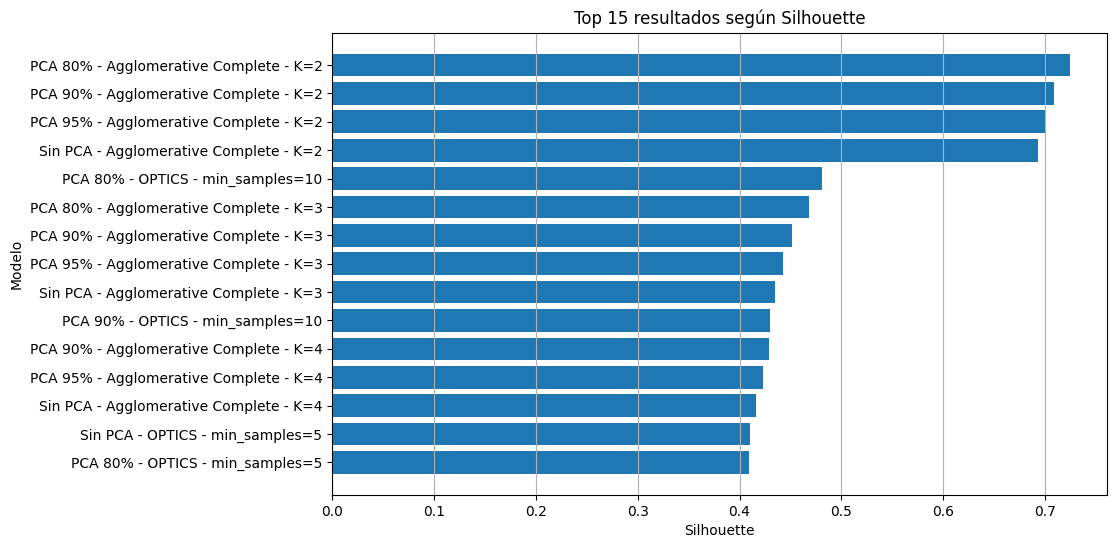

In [ ]:
# Gráfico: Top 15 modelos por Silhouette
top_15 = resultados_ordenados.head(15).copy()

def nombre_modelo(row):
    if pd.notna(row["K"]):
        parametro = "K=" + str(int(row["K"]))
    elif pd.notna(row["eps"]):
        parametro = "eps=" + str(row["eps"])
    else:
        parametro = "min_samples=" + str(int(row["min_samples"]))
    return row["Base"] + " - " + row["Modelo"] + " - " + parametro

top_15["Nombre"] = top_15.apply(nombre_modelo, axis=1)

plt.figure(figsize=(10, 6))
plt.barh(top_15["Nombre"], top_15["Silhouette"])
plt.xlabel("Silhouette")
plt.ylabel("Modelo")
plt.title("Top 15 resultados según Silhouette")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.show()


## Justificación técnica del Punto 3

En este punto se realizó un *challenge* entre cinco algoritmos de clustering sobre cuatro bases: una sin PCA y tres con PCA según umbrales de varianza explicada de 80%, 90% y 95%.

La comparación incluye modelos basados en distancia, jerárquicos y densidad. Esto permite analizar si la base **House Prices** se agrupa mejor por cercanía entre observaciones o por concentración local de puntos.

La tabla ordenada por Silhouette muestra el desempeño métrico de cada combinación. Sin embargo, un buen valor de Silhouette no garantiza por sí solo que el modelo sea útil desde el punto de vista práctico. Por esta razón, en el Punto 4 se incorpora un criterio adicional de representatividad mínima de cluster.


# Punto 4. Evaluación de modelos y selección final

La evaluación se realiza con tres métricas internas:

- **Silhouette:** más alto es mejor. Evalúa cohesión interna y separación entre clusters.
- **Davies-Bouldin:** más bajo es mejor. Evalúa dispersión interna y separación entre grupos.
- **Calinski-Harabasz:** más alto es mejor. Evalúa la relación entre varianza entre clusters y dentro de los clusters.

Además, se incorpora un criterio práctico: el cluster más pequeño debe representar al menos el **5% de la base**. Como la base tiene 1460 viviendas, esto equivale aproximadamente a **73 observaciones**. Esta condición evita seleccionar modelos que generan clusters de una sola vivienda.

El criterio de 5% no corresponde a una regla universal, sino a una decisión metodológica de representatividad para este trabajo.


In [ ]:
# Selección del mejor modelo considerando métrica + representatividad
MIN_CLUSTER_PCT = 0.05

resultados_practicos = resultados_ordenados[
    (resultados_ordenados["Silhouette"].notna()) &
    (resultados_ordenados["Clusters"] >= 2) &
    (resultados_ordenados["Porcentaje_agrupado"] >= 0.90) &
    (resultados_ordenados["Min_cluster_pct"] >= MIN_CLUSTER_PCT)
].copy()

resultados_practicos = resultados_practicos.sort_values(
    by="Silhouette",
    ascending=False
).reset_index(drop=True)

print("Modelos que cumplen criterio práctico de cluster mínimo >= 5%:", len(resultados_practicos))
display(resultados_practicos.head(20))

if len(resultados_practicos) > 0:
    mejor_modelo = resultados_practicos.iloc[0]
else:
    mejor_modelo = resultados_ordenados.iloc[0]

print("Modelo final seleccionado:")
display(pd.DataFrame([mejor_modelo]))


Modelos que cumplen criterio práctico de cluster mínimo >= 5%: 28


,Base,Modelo,K,eps,min_samples,Clusters,Ruido,Porcentaje_agrupado,Min_cluster,Max_cluster,Min_cluster_pct,Max_cluster_pct,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,PCA 80%,K-Means,2.0,NaN,NaN,2,0,1.0,613,847,0.4199,0.5801,0.078955,3.051620,129.395074
1,PCA 80%,K-Means,4.0,NaN,NaN,4,0,1.0,83,523,0.0568,0.3582,0.072538,3.161689,88.704287
2,PCA 90%,K-Means,2.0,NaN,NaN,2,0,1.0,614,846,0.4205,0.5795,0.068685,3.271203,113.790611
3,PCA 80%,K-Means,3.0,NaN,NaN,3,0,1.0,351,590,0.2404,0.4041,0.066411,3.300744,105.858691
4,PCA 95%,K-Means,2.0,NaN,NaN,2,0,1.0,614,846,0.4205,0.5795,0.064415,3.374491,107.461002
5,Sin PCA,K-Means,2.0,NaN,NaN,2,0,1.0,614,846,0.4205,0.5795,0.060557,3.474205,101.927462
6,PCA 95%,K-Means,4.0,NaN,NaN,4,0,1.0,83,576,0.0568,0.3945,0.059587,3.455059,72.926929
7,PCA 80%,Agglomerative Ward,2.0,NaN,NaN,2,0,1.0,529,931,0.3623,0.6377,0.056852,3.295850,102.894594
8,PCA 80%,K-Means,7.0,NaN,NaN,7,0,1.0,83,351,0.0568,0.2404,0.055983,3.016948,67.331137
9,PCA 90%,K-Means,4.0,NaN,NaN,4,0,1.0,157,532,0.1075,0.3644,0.055168,3.243694,77.248783


Modelo final seleccionado:


,Base,Modelo,K,eps,min_samples,Clusters,Ruido,Porcentaje_agrupado,Min_cluster,Max_cluster,Min_cluster_pct,Max_cluster_pct,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,PCA 80%,K-Means,2.0,NaN,NaN,2,0,1.0,613,847,0.4199,0.5801,0.078955,3.05162,129.395074


## Justificación del criterio de selección

La selección del modelo no se realiza únicamente por Silhouette. Un modelo puede obtener un alto Silhouette si separa una observación atípica del resto, pero eso no necesariamente representa una segmentación útil.

Por esta razón, se incorpora un criterio de tamaño mínimo: el cluster más pequeño debe contener al menos 5% de la base. Esta regla complementa las métricas internas con una condición de representatividad, favoreciendo modelos que generen grupos interpretables y no clusters formados por casos aislados.


In [ ]:
# Reconstruir el modelo final seleccionado
base_final = mejor_modelo["Base"]
modelo_final_nombre = mejor_modelo["Modelo"]
X_final = X_por_base[base_final]

if modelo_final_nombre == "K-Means":
    modelo_final = KMeans(
        n_clusters=int(mejor_modelo["K"]),
        random_state=RANDOM_STATE,
        n_init=10
    )
    labels_final = modelo_final.fit_predict(X_final)

elif modelo_final_nombre == "Agglomerative Ward":
    modelo_final = AgglomerativeClustering(
        n_clusters=int(mejor_modelo["K"]),
        linkage="ward"
    )
    labels_final = modelo_final.fit_predict(X_final)

elif modelo_final_nombre == "Agglomerative Complete":
    modelo_final = AgglomerativeClustering(
        n_clusters=int(mejor_modelo["K"]),
        linkage="complete"
    )
    labels_final = modelo_final.fit_predict(X_final)

elif modelo_final_nombre == "DBSCAN":
    modelo_final = DBSCAN(
        eps=float(mejor_modelo["eps"]),
        min_samples=int(mejor_modelo["min_samples"])
    )
    labels_final = modelo_final.fit_predict(X_final)

elif modelo_final_nombre == "OPTICS":
    modelo_final = OPTICS(
        min_samples=int(mejor_modelo["min_samples"]),
        xi=0.05
    )
    labels_final = modelo_final.fit_predict(X_final)

# Crear base para interpretación
_df_cluster = df.copy()
_df_cluster["cluster"] = labels_final

distribucion_clusters = pd.Series(labels_final).value_counts().sort_index().reset_index()
distribucion_clusters.columns = ["Cluster", "Cantidad"]
distribucion_clusters["Porcentaje"] = (distribucion_clusters["Cantidad"] / len(labels_final) * 100).round(2)

display(distribucion_clusters)


,Cluster,Cantidad,Porcentaje
0,0,847,58.01
1,1,613,41.99


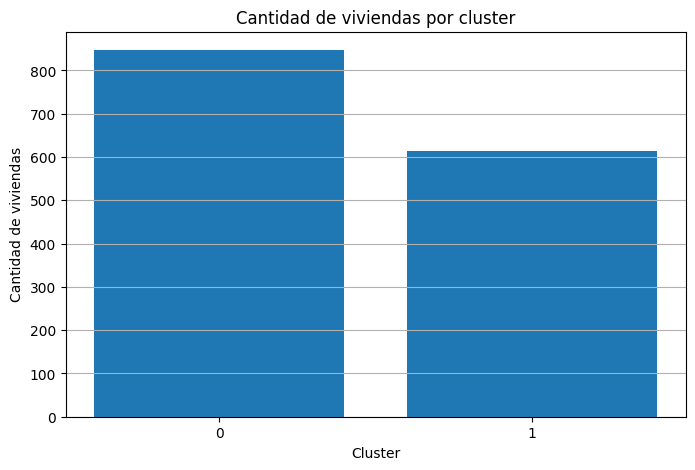

In [ ]:
# Gráfico de distribución de clusters
plt.figure(figsize=(8,5))
plt.bar(distribucion_clusters["Cluster"].astype(str), distribucion_clusters["Cantidad"])
plt.xlabel("Cluster")
plt.ylabel("Cantidad de viviendas")
plt.title("Cantidad de viviendas por cluster")
plt.grid(axis="y")
plt.show()


In [ ]:
# Reincorporar SalePrice para interpretación
precio_por_cluster = (
    _df_cluster
    .groupby("cluster")[TARGET]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
    .sort_values(by="mean")
)

print("SalePrice por cluster:")
display(precio_por_cluster)


SalePrice por cluster:


,count,mean,median,min,max
cluster,,,,,
0,847,138808.02,135000.0,61815.97,442567.01
1,613,236740.91,217000.0,130000.00,442567.01


<Figure size 800x500 with 0 Axes>

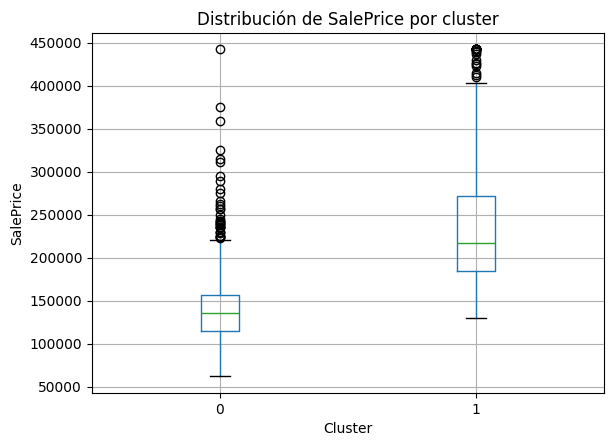

In [ ]:
# Boxplot de SalePrice por cluster
plt.figure(figsize=(8,5))
_df_cluster.boxplot(column=TARGET, by="cluster")
plt.title("Distribución de SalePrice por cluster")
plt.suptitle("")
plt.xlabel("Cluster")
plt.ylabel("SalePrice")
plt.show()


In [ ]:
# Características principales por cluster
variables_interpretacion = [
    "OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF", "YearBuilt", "FullBath", "LotArea"
]

variables_disponibles = [col for col in variables_interpretacion if col in _df_cluster.columns]

caracteristicas_cluster = (
    _df_cluster
    .groupby("cluster")[variables_disponibles]
    .mean()
    .round(2)
)

print("Características principales por cluster:")
display(caracteristicas_cluster)


Características principales por cluster:


,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,LotArea
cluster,,,,,,,
0,5.29,1324.40,1.40,907.44,1951.62,1.29,9719.33
1,7.22,1767.13,2.27,1248.43,1998.76,1.96,10537.88


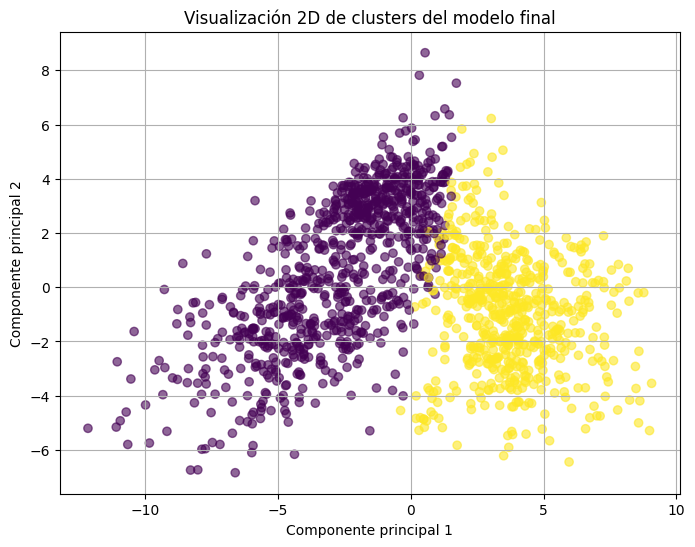

In [ ]:
# Visualización 2D del modelo final
# Se usa PCA a 2 componentes solo para visualizar, no para entrenar necesariamente.
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca_2d.fit_transform(X_final)

plt.figure(figsize=(8,6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels_final, alpha=0.6)
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title("Visualización 2D de clusters del modelo final")
plt.grid(True)
plt.show()


In [ ]:
# Resumen final del modelo seleccionado
print("Modelo final seleccionado")
print("Base:", mejor_modelo["Base"])
print("Modelo:", mejor_modelo["Modelo"])
print("K:", mejor_modelo["K"])
print("Clusters:", mejor_modelo["Clusters"])
print("Ruido:", mejor_modelo["Ruido"])
print("Porcentaje agrupado:", round(float(mejor_modelo["Porcentaje_agrupado"]) * 100, 2), "%")
print("Tamaño mínimo de cluster:", mejor_modelo["Min_cluster"])
print("Porcentaje mínimo de cluster:", round(float(mejor_modelo["Min_cluster_pct"]) * 100, 2), "%")
print("Silhouette:", round(float(mejor_modelo["Silhouette"]), 4))
print("Davies-Bouldin:", round(float(mejor_modelo["Davies_Bouldin"]), 4))
print("Calinski-Harabasz:", round(float(mejor_modelo["Calinski_Harabasz"]), 4))


Modelo final seleccionado
Base: PCA 80%
Modelo: K-Means
K: 2.0
Clusters: 2
Ruido: 0
Porcentaje agrupado: 100.0 %
Tamaño mínimo de cluster: 613
Porcentaje mínimo de cluster: 41.99 %
Silhouette: 0.079
Davies-Bouldin: 3.0516
Calinski-Harabasz: 129.3951


## 4.1 Análisis adicional: ¿2 clusters son suficientes?

Para validar si `K = 2` es suficiente, se comparan modelos K-Means con `K = 2`, `K = 3` y `K = 4` sobre la base PCA 80%, que fue la base del modelo seleccionado. Esta revisión permite observar si aumentar el número de clusters mejora la interpretación o solo fragmenta la base.


In [ ]:
# Comparación entre K=2, K=3 y K=4 para K-Means con PCA 80%
X_analisis_k = X_por_base["PCA 80%"]

resumen_k = []
resultados_por_k = {}

for k in [2, 3, 4]:
    modelo_k = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    labels_k = modelo_k.fit_predict(X_analisis_k)

    sil = silhouette_score(X_analisis_k, labels_k)
    db = davies_bouldin_score(X_analisis_k, labels_k)
    ch = calinski_harabasz_score(X_analisis_k, labels_k)

    distribucion_k = (
        pd.Series(labels_k)
        .value_counts()
        .sort_index()
        .reset_index()
    )
    distribucion_k.columns = ["Cluster", "Cantidad"]
    distribucion_k["Porcentaje"] = (
        distribucion_k["Cantidad"] / len(labels_k) * 100
    ).round(2)

    min_cluster = distribucion_k["Cantidad"].min()
    min_cluster_pct = distribucion_k["Porcentaje"].min()

    resumen_k.append({
        "K": k,
        "Silhouette": round(sil, 4),
        "Davies_Bouldin": round(db, 4),
        "Calinski_Harabasz": round(ch, 4),
        "Cluster mínimo": min_cluster,
        "% cluster mínimo": min_cluster_pct
    })

    df_k = df.copy()
    df_k["cluster"] = labels_k

    precio_k = (
        df_k
        .groupby("cluster")[TARGET]
        .agg(["count", "mean", "median", "min", "max"])
        .round(2)
        .sort_values(by="mean")
    )

    caracteristicas_k = (
        df_k
        .groupby("cluster")[variables_disponibles]
        .mean()
        .round(2)
    )

    resultados_por_k[k] = {
        "labels": labels_k,
        "distribucion": distribucion_k,
        "precio": precio_k,
        "caracteristicas": caracteristicas_k
    }

resumen_k = pd.DataFrame(resumen_k)

print("Comparación de K=2, K=3 y K=4")
display(resumen_k)


Comparación de K=2, K=3 y K=4


,K,Silhouette,Davies_Bouldin,Calinski_Harabasz,Cluster mínimo,% cluster mínimo
0,2,0.0790,3.0516,129.3951,613,41.99
1,3,0.0664,3.3007,105.8587,351,24.04
2,4,0.0725,3.1617,88.7043,83,5.68


In [ ]:
# Mostrar detalles por cada K evaluado
for k in [2, 3, 4]:
    print("\n" + "="*60)
    print(f"RESULTADOS PARA K = {k}")
    print("="*60)

    print("\nDistribución de viviendas por cluster:")
    display(resultados_por_k[k]["distribucion"])

    print("\nSalePrice por cluster:")
    display(resultados_por_k[k]["precio"])

    print("\nCaracterísticas principales por cluster:")
    display(resultados_por_k[k]["caracteristicas"])



RESULTADOS PARA K = 2

Distribución de viviendas por cluster:


,Cluster,Cantidad,Porcentaje
0,0,847,58.01
1,1,613,41.99



SalePrice por cluster:


,count,mean,median,min,max
cluster,,,,,
0,847,138808.02,135000.0,61815.97,442567.01
1,613,236740.91,217000.0,130000.00,442567.01



Características principales por cluster:


...

,Cluster,Cantidad,Porcentaje
0,0,523,35.82
1,1,83,5.68
2,2,336,23.01
3,3,518,35.48



SalePrice por cluster:


,count,mean,median,min,max
cluster,,,,,
1,83,104595.71,100000.0,61815.97,200500.00
2,336,132571.32,122700.0,61815.97,442567.01
3,518,161858.03,150950.0,61815.97,385000.00
0,523,240200.20,222000.0,130000.00,442567.01



Características principales por cluster:


,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,LotArea
cluster,,,,,,,
0,7.32,1753.74,2.31,1247.96,2002.02,1.98,10075.68
1,4.69,1200.81,0.02,773.10,1942.44,1.33,7513.69
2,5.32,1441.63,1.47,749.43,1935.82,1.33,8672.25
3,5.61,1358.62,1.69,1091.19,1968.24,1.36,11360.80


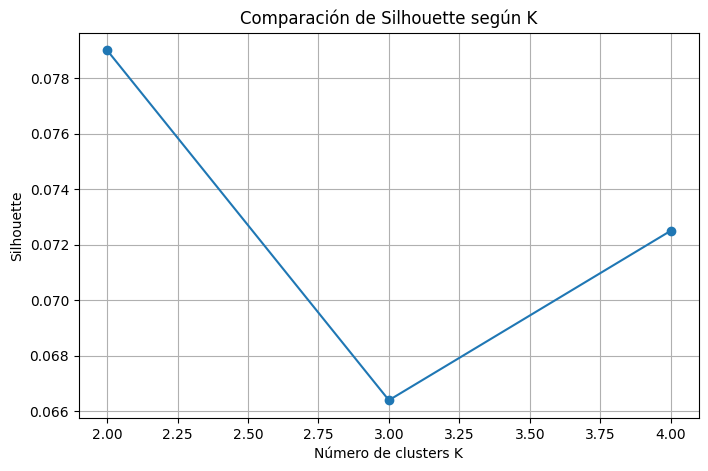

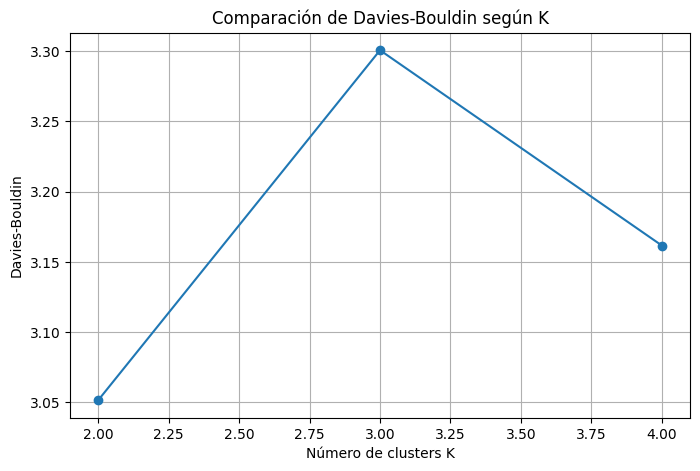

In [ ]:
# Gráfico comparativo de métricas para K=2, K=3 y K=4
plt.figure(figsize=(8,5))
plt.plot(resumen_k["K"], resumen_k["Silhouette"], marker="o")
plt.xlabel("Número de clusters K")
plt.ylabel("Silhouette")
plt.title("Comparación de Silhouette según K")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(resumen_k["K"], resumen_k["Davies_Bouldin"], marker="o")
plt.xlabel("Número de clusters K")
plt.ylabel("Davies-Bouldin")
plt.title("Comparación de Davies-Bouldin según K")
plt.grid(True)
plt.show()


## Interpretación final del Punto 4

El modelo seleccionado no corresponde al mayor Silhouette absoluto, sino al mejor resultado dentro de los modelos que cumplen una condición mínima de representatividad. Esta decisión evita seleccionar modelos que separan una observación aislada, priorizando una segmentación más útil e interpretable.

Con `K = 2`, el modelo separa la base en dos grupos representativos. El **cluster 0** agrupa viviendas de menor valor relativo, más antiguas, con menor calidad general, menor superficie habitable, menor capacidad de garaje y menos baños. En cambio, el **cluster 1** agrupa viviendas de mayor valor relativo, más nuevas, con mejor calidad general, mayor superficie, mayor capacidad de garaje y más baños.

La comparación entre `K = 2`, `K = 3` y `K = 4` permite confirmar que `K = 2` es suficiente para una primera segmentación exploratoria. `K = 3` entrega una lectura más detallada, pero sus métricas internas son inferiores. `K = 4` fragmenta más la base y genera un cluster más pequeño. Por lo tanto, se mantiene `K = 2` como modelo final, ya que ofrece el mejor equilibrio entre desempeño métrico, representatividad e interpretación respecto a `SalePrice`.


# Punto 5. Carga del cuaderno en GitHub

Para cumplir con la entrega del cuaderno Python, el archivo final debe ser cargado en el repositorio del grupo en GitHub. Esto permite dejar respaldo del trabajo desarrollado, mantener trazabilidad y facilitar el acceso al cuaderno utilizado para el análisis.

**Repositorio GitHub:**  
https://github.com/jonathanastudillo-lab/Ejercicio/blob/main/trabajo_unidad_3_ml_v2.ipynb




## Conclusión

En este trabajo se aplicaron algoritmos de aprendizaje no supervisado sobre la base **House Prices**, utilizando una metodología basada en preparación de datos, ingeniería de variables, codificación categórica, normalización, PCA y evaluación de modelos de clustering.

La base inicial contenía **1460 viviendas y 73 columnas**, con **2073 valores nulos**. Para evitar sesgo, se separó `SalePrice` desde el inicio, quedando **72 variables explicativas** para el entrenamiento. Luego, se realizó ingeniería de variables: `MSSubClass` fue tratada como categórica, se eliminaron **2 variables temporales** (`MoSold` y `YrSold`), se transformaron **17 variables ordinales** a escala numérica y se agruparon **73 categorías poco frecuentes** bajo la etiqueta `Otros`.

Después del One-Hot Encoding completo y la normalización, la base final quedó con **172 columnas**. Posteriormente, se aplicó PCA con tres umbrales de varianza: **80%, 90% y 95%**, obteniendo **61, 83 y 99 componentes**, respectivamente. Esta comparación permitió evaluar si los algoritmos funcionaban mejor con toda la información transformada o con una representación más compacta.

En el challenge se evaluaron **132 combinaciones de modelos**, considerando algoritmos basados en distancia, jerárquicos y de densidad. La selección final no se realizó únicamente por Silhouette, sino incorporando un criterio práctico de representatividad: el cluster más pequeño debía contener al menos el **5% de la base**, equivalente a aproximadamente **73 viviendas**.

El modelo seleccionado fue **K-Means sobre la base PCA 80% con K = 2**. Aunque su Silhouette fue bajo (**0,079**), el modelo agrupó el **100% de las observaciones**, no generó ruido y formó dos clusters representativos: uno con **847 viviendas** y otro con **613 viviendas**.

Al reincorporar `SalePrice`, se observó una diferencia coherente entre los grupos. El cluster 0 presentó un precio medio de **138.808**, mientras que el cluster 1 alcanzó un precio medio de **236.741**. Además, el cluster de mayor precio mostró mejor calidad general, mayor superficie habitable, mayor capacidad de garaje, más baños y viviendas más recientes.

Por lo tanto, el resultado debe interpretarse como una segmentación exploratoria en dos grupos generales: viviendas de menor valor relativo y viviendas de mayor valor relativo. El aprendizaje principal es que en clustering no basta con seleccionar el modelo con la mejor métrica interna; también es necesario revisar la representatividad de los grupos y su interpretación respecto al problema.

# Bibliografía

- Kaggle. (s. f.). *House Prices - Advanced Regression Techniques*. Kaggle Competition Dataset. https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data
- RPubs. (s. f.). *House Sales / House Prices dataset analysis*. https://rpubs.com/nhngoc02/housesales
- Scikit-learn. (s. f.). *Clustering algorithms and evaluation metrics*. Documentación oficial.
- Abdi, H., & Williams, L. J. (2010). *Principal component analysis*. Wiley Interdisciplinary Reviews: Computational Statistics.
